# Sistema de Decisión Global con Aprendizaje de Umbrales

## Planteamiento del Problema

Tenemos $N$ sistemas de decisión independientes. Cada sistema $i$:
- Observa un **score** $S_i \in \mathbb{R}$ (valor continuo)
- Tiene un **umbral fijo** $\tau_i \in \mathbb{R}$ que **aprende durante el entrenamiento**
- Decide: $$d_i = \begin{cases} 1 & \text{si } S_i \geq \tau_i \\ 0 & \text{si } S_i < \tau_i \end{cases}$$

El **sistema global** agrega las decisiones locales mediante una regla $\phi$:
$$D_g = \phi(d_1, \dots, d_N)$$

En este caso, usamos mayoría: $D_g = 1$ si $\sum_{i=1}^N d_i > N/2$, sino $0$.

**Objetivo:** Maximizar la precisión global $\mathbb{P}(D_g = \Theta)$, donde $\Theta \in \{0,1\}$ es la verdad del mundo.

## Distribuciones de los Agentes

Cada agente tiene **distribuciones diferentes** bajo $H_0$ y $H_1$:

| Agente | Bajo $H_0$ ($\Theta=0$) | Bajo $H_1$ ($\Theta=1$) |
|--------|------------------------|------------------------|
| 0 | $\mathcal{N}(0, 1)$ | $\mathcal{N}(2, 1)$ |
| 1 | $\mathcal{N}(2, 1)$ | $\mathcal{N}(4, 1)$ |
| 2 | $\mathcal{N}(0, 4)$ | $\mathcal{N}(2, 4)$ |

## ¿Cómo se aprende el umbral?

Durante el **entrenamiento** (donde conocemos $\Theta$), cada agente recibe una **recompensa**:

$$r_i = -\beta_i |d_i - D_g| + \mathbf{1}_{d_i = \Theta} + \alpha_i \cdot \mathbf{1}_{D_g = \Theta}$$

Donde:
- $\beta_i \geq 0$: penalización por **desacuerdo** con la decisión global
- $\alpha_i \geq 0$: importancia del **acierto global** para el agente
- $\mathbf{1}_{\text{condición}}$ es la función indicadora (vale 1 si se cumple, 0 si no)

El umbral se actualiza usando **gradiente aproximado**:

$$\tau_i \leftarrow \tau_i + \eta \cdot \frac{\partial r_i}{\partial \tau_i}$$

Donde $\eta$ es la **tasa de aprendizaje**.

## 1. Parámetros del Sistema 

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARÁMETROS DEL SISTEMA - AJUSTAR SEGÚN NECESIDAD
# ============================================================

# ---- Arquitectura ----
N_AGENTES = 4
REGLA = 'mayoria'

# ---- Incentivos (teoría de juegos) ----
ALPHAS = [1.0, 1.0, 1.0, 1.0]
BETAS = [0.25, 0.25, 0.25, 0.25]

# ---- Aprendizaje de umbrales ----
LR_UMBRAL = 0.0005
UMBRALES_INICIALES = [0.0, 0.0, 0.0, 0.0]

# ---- Entrenamiento ----
N_EPISODIOS = 300
PASOS_POR_EPISODIO = 200
EPSILON_EXPLORACION = 0.1
EVALUAR_CADA = 10

# ---- Distribuciones de los agentes ----
# Cada agente tiene (mu0, sigma0) bajo H0 y (mu1, sigma1) bajo H1
#AGENTES_PARAMS = [
#    {'mu0': 0, 'sigma0': 4, 'mu1': 4, 'sigma1': 4},   # Agente 0 
#    {'mu0': 0, 'sigma0': 4, 'mu1': 1, 'sigma1': 4},   # Agente 1
#    {'mu0': 0, 'sigma0': 1, 'mu1': 4, 'sigma1': 1},    # Agente 2 (sigma=2, varianza=4)
#    {'mu0': 0, 'sigma0': 1, 'mu1': 1, 'sigma1': 1}    # Agente 2 (sigma=2, varianza=4)
#]

AGENTES_PARAMS = [
    {'mu0': 0, 'sigma0': 1, 'mu1': 4, 'sigma1': 1},   # Agente 0 
    {'mu0': 0, 'sigma0': 1, 'mu1': 2, 'sigma1': 1},   # Agente 1
    {'mu0': 0, 'sigma0': 1, 'mu1': 7, 'sigma1': 1},    # Agente 2 (sigma=2, varianza=4)
    {'mu0': 0, 'sigma0': 1, 'mu1': 1, 'sigma1': 1}    # Agente 2 (sigma=2, varianza=4)
]

# Rango para visualización (basado en todas las distribuciones)
RANGO_SCORES = (-4, 8)

VERBOSE = True

print("=" * 60)
print("CONFIGURACIÓN DEL SISTEMA")
print("=" * 60)
print(f"Número de agentes: {N_AGENTES}")
print(f"Regla de agregación: {REGLA}")
print(f"Alphas: {ALPHAS}")
print(f"Betas: {BETAS}")
print(f"Tasa de aprendizaje: {LR_UMBRAL}")
print(f"Umbrales iniciales: {UMBRALES_INICIALES}")
print(f"\nDistribuciones de cada agente:")
for i, p in enumerate(AGENTES_PARAMS):
    print(f"  Agente {i}: H0 ~ N({p['mu0']}, {p['sigma0']**2}), H1 ~ N({p['mu1']}, {p['sigma1']**2})")

CONFIGURACIÓN DEL SISTEMA
Número de agentes: 4
Regla de agregación: mayoria
Alphas: [1.0, 1.0, 1.0, 1.0]
Betas: [0.25, 0.25, 0.25, 0.25]
Tasa de aprendizaje: 0.0005
Umbrales iniciales: [0.0, 0.0, 0.0, 0.0]

Distribuciones de cada agente:
  Agente 0: H0 ~ N(0, 1), H1 ~ N(4, 1)
  Agente 1: H0 ~ N(0, 1), H1 ~ N(2, 1)
  Agente 2: H0 ~ N(0, 1), H1 ~ N(7, 1)
  Agente 3: H0 ~ N(0, 1), H1 ~ N(1, 1)


## 2. Clase Agente con Umbral Aprendible

In [60]:
class AgenteUmbral:
    def __init__(self, id_agente, alpha, beta, umbral_inicial=0.0,
                 lr_umbral=0.01, rango_scores=(-4, 8)):
        self.id = id_agente
        self.alpha = alpha
        self.beta = beta
        self.tau = umbral_inicial
        self.lr = lr_umbral
        self.rango_min, self.rango_max = rango_scores
        self.historial_tau = [umbral_inicial]
    
    def decidir(self, score, epsilon=0.0):
        if np.random.random() < epsilon:
            return np.random.randint(0, 2)
        return 1 if score >= self.tau else 0
    
    def calcular_recompensa(self, d_i, D_g, theta):
        r_coord = -self.beta * abs(d_i - D_g)
        r_local = 1.0 if d_i == theta else 0.0
        r_global = 1.0 if D_g == theta else 0.0
        return r_coord + r_local + self.alpha * r_global
    
    def actualizar_umbral(self, score, d_i, D_g, theta):
        delta = 0.05
        tau_up = self.tau + delta
        d_up = 1 if score >= tau_up else 0
        r_up = self.calcular_recompensa(d_up, D_g, theta)
        tau_down = self.tau - delta
        d_down = 1 if score >= tau_down else 0
        r_down = self.calcular_recompensa(d_down, D_g, theta)
        gradiente = (r_up - r_down) / (2 * delta)
        self.tau = self.tau + self.lr * gradiente
        self.tau = np.clip(self.tau, self.rango_min, self.rango_max)
        self.historial_tau.append(self.tau)
        return self.calcular_recompensa(d_i, D_g, theta)
    
    def obtener_umbral(self):
        return self.tau

## 3. Generar Datos con Distribuciones por Agente

In [61]:
def generar_datos_heterogeneos(n_muestras=10000, agentes_params=None, p_theta=0.5):
    """
    Genera datos donde cada agente tiene su propia distribución.
    
    Args:
        n_muestras: Número de muestras
        agentes_params: Lista de dicts con {'mu0','sigma0','mu1','sigma1'}
        p_theta: Probabilidad de H1
    """
    n_agentes = len(agentes_params)
    theta = np.random.binomial(1, p_theta, n_muestras)
    data = {'theta': theta}
    
    for i, params in enumerate(agentes_params):
        scores = np.zeros(n_muestras)
        for j, t in enumerate(theta):
            if t == 0:
                mu = params['mu0']
                sigma = params['sigma0']
            else:
                mu = params['mu1']
                sigma = params['sigma1']
            scores[j] = np.random.normal(mu, sigma)
        data[f'score_{i}'] = scores
    
    return pd.DataFrame(data)

# Generar datos
df_train = generar_datos_heterogeneos(n_muestras=10000, agentes_params=AGENTES_PARAMS)
df_val = generar_datos_heterogeneos(n_muestras=2000, agentes_params=AGENTES_PARAMS)
df_test = generar_datos_heterogeneos(n_muestras=2000, agentes_params=AGENTES_PARAMS)

print("Datos generados con distribuciones heterogéneas:")
print(f"  Entrenamiento: {len(df_train)} muestras")
print(f"  Validación: {len(df_val)} muestras")
print(f"  Prueba: {len(df_test)} muestras")
print(f"\nDistribución de Theta: {df_train['theta'].value_counts().to_dict()}")

# Mostrar estadísticas de cada agente
print("\nEstadísticas de los datos generados:")
for i in range(N_AGENTES):
    print(f"\nAgente {i}:")
    print(f"  H0: media={df_train[df_train['theta']==0][f'score_{i}'].mean():.2f}, "
          f"std={df_train[df_train['theta']==0][f'score_{i}'].std():.2f}")
    print(f"  H1: media={df_train[df_train['theta']==1][f'score_{i}'].mean():.2f}, "
          f"std={df_train[df_train['theta']==1][f'score_{i}'].std():.2f}")

Datos generados con distribuciones heterogéneas:
  Entrenamiento: 10000 muestras
  Validación: 2000 muestras
  Prueba: 2000 muestras

Distribución de Theta: {0: 5008, 1: 4992}

Estadísticas de los datos generados:

Agente 0:
  H0: media=0.00, std=1.01
  H1: media=3.98, std=0.99

Agente 1:
  H0: media=-0.01, std=1.01
  H1: media=1.99, std=0.99

Agente 2:
  H0: media=-0.03, std=1.01
  H1: media=7.01, std=0.99

Agente 3:
  H0: media=0.02, std=1.02
  H1: media=0.99, std=1.01


## 4. Clase Coordinador Global

In [62]:
class CoordinadorGlobal:
    def __init__(self, n_agentes, alphas=None, betas=None, regla='mayoria',
                 umbrales_iniciales=None, lr_umbral=0.01, rango_scores=(-4, 8)):
        self.n_agentes = n_agentes
        self.regla = regla
        if alphas is None:
            alphas = [1.0] * n_agentes
        if betas is None:
            betas = [0.3] * n_agentes
        if umbrales_iniciales is None:
            umbrales_iniciales = [0.0] * n_agentes
        self.agentes = [
            AgenteUmbral(i, alphas[i], betas[i], umbrales_iniciales[i],
                        lr_umbral, rango_scores)
            for i in range(n_agentes)
        ]
        self.historial_precision_validacion = []
        self.historial_episodios = []
        self.historial_umbrales = [[] for _ in range(n_agentes)]
    
    def agregar_decisiones(self, decisiones):
        if self.regla == 'mayoria':
            return 1 if sum(decisiones) > self.n_agentes / 2 else 0
        elif self.regla == 'unanimidad':
            return 1 if all(d == 1 for d in decisiones) else 0
        elif self.regla == 'veto':
            return 1 if any(d == 1 for d in decisiones) else 0
        else:
            return 1 if sum(decisiones) > self.n_agentes / 2 else 0
    
    def evaluar_precision(self, df, columnas_scores, columna_theta):
        aciertos = 0
        total = len(df)
        for idx, fila in df.iterrows():
            scores = [fila[col] for col in columnas_scores]
            theta = int(fila[columna_theta])
            decisiones = []
            for agente in self.agentes:
                d_i = agente.decidir(scores[agente.id], epsilon=0.0)
                decisiones.append(d_i)
            D_g = self.agregar_decisiones(decisiones)
            if D_g == theta:
                aciertos += 1
        return aciertos / total if total > 0 else 0.0
    
    def entrenar(self, df_train, df_val, columnas_scores, columna_theta,
                 n_episodios=100, pasos_por_episodio=200, epsilon=0.1,
                 evaluar_cada=10, verbose=True):
        n_train = len(df_train)
        for ep in range(n_episodios):
            for paso in range(pasos_por_episodio):
                idx = np.random.randint(0, n_train)
                fila = df_train.iloc[idx]
                scores = [fila[col] for col in columnas_scores]
                theta = int(fila[columna_theta])
                decisiones = []
                for agente in self.agentes:
                    d_i = agente.decidir(scores[agente.id], epsilon)
                    decisiones.append(d_i)
                D_g = self.agregar_decisiones(decisiones)
                for agente in self.agentes:
                    d_i = decisiones[agente.id]
                    agente.actualizar_umbral(scores[agente.id], d_i, D_g, theta)
            for i, agente in enumerate(self.agentes):
                self.historial_umbrales[i].append(agente.tau)
            if (ep + 1) % evaluar_cada == 0:
                precision = self.evaluar_precision(df_val, columnas_scores, columna_theta)
                self.historial_precision_validacion.append(precision)
                self.historial_episodios.append(ep + 1)
                if verbose:
                    umbrales_str = ", ".join([f"{a.tau:.3f}" for a in self.agentes])
                    print(f"Episodio {ep+1:3d}/{n_episodios} | Precision val: {precision:.4f} | Umbrales: [{umbrales_str}]")
        return self.historial_precision_validacion
    
    def predecir(self, df, columnas_scores):
        df_resultado = df.copy()
        decisiones_globales = []
        for idx, fila in df_resultado.iterrows():
            scores = [fila[col] for col in columnas_scores]
            decisiones = []
            for agente in self.agentes:
                d_i = agente.decidir(scores[agente.id], epsilon=0.0)
                decisiones.append(d_i)
            D_g = self.agregar_decisiones(decisiones)
            decisiones_globales.append(D_g)
        df_resultado['D_g'] = decisiones_globales
        return df_resultado
    
    def obtener_umbrales(self):
        return [agente.tau for agente in self.agentes]

## 5. Entrenamiento

In [63]:
coordinador = CoordinadorGlobal(
    n_agentes=N_AGENTES,
    alphas=ALPHAS,
    betas=BETAS,
    regla=REGLA,
    umbrales_iniciales=UMBRALES_INICIALES,
    lr_umbral=LR_UMBRAL,
    rango_scores=RANGO_SCORES
)

print("=" * 60)
print("INICIANDO ENTRENAMIENTO")
print("=" * 60)

precisiones_val = coordinador.entrenar(
    df_train=df_train,
    df_val=df_val,
    columnas_scores=[f'score_{i}' for i in range(N_AGENTES)],
    columna_theta='theta',
    n_episodios=N_EPISODIOS,
    pasos_por_episodio=PASOS_POR_EPISODIO,
    epsilon=EPSILON_EXPLORACION,
    evaluar_cada=EVALUAR_CADA,
    verbose=VERBOSE
)

print("-" * 60)
print("ENTRENAMIENTO COMPLETADO")
print("=" * 60)

umbrales_finales = coordinador.obtener_umbrales()
print(f"\nUmbrales aprendidos:")
for i, tau in enumerate(umbrales_finales):
    print(f"  Agente {i}: $\\tau_{i} = {tau:.3f}$")
if precisiones_val:
    print(f"\nMejor precisión en validación: {max(precisiones_val):.4f}")

INICIANDO ENTRENAMIENTO
Episodio  10/300 | Precision val: 0.8950 | Umbrales: [0.164, 0.258, 0.249, 0.064]
Episodio  20/300 | Precision val: 0.9200 | Umbrales: [0.406, 0.391, 0.432, 0.105]
Episodio  30/300 | Precision val: 0.9470 | Umbrales: [0.620, 0.534, 0.676, 0.179]
Episodio  40/300 | Precision val: 0.9570 | Umbrales: [0.810, 0.657, 0.830, 0.219]
Episodio  50/300 | Precision val: 0.9665 | Umbrales: [1.032, 0.814, 0.975, 0.316]
Episodio  60/300 | Precision val: 0.9695 | Umbrales: [1.146, 0.841, 1.075, 0.420]
Episodio  70/300 | Precision val: 0.9725 | Umbrales: [1.280, 0.841, 1.188, 0.445]
Episodio  80/300 | Precision val: 0.9720 | Umbrales: [1.380, 0.892, 1.326, 0.442]
Episodio  90/300 | Precision val: 0.9730 | Umbrales: [1.496, 0.916, 1.414, 0.499]
Episodio 100/300 | Precision val: 0.9745 | Umbrales: [1.553, 0.945, 1.511, 0.476]
Episodio 110/300 | Precision val: 0.9695 | Umbrales: [1.614, 0.954, 1.580, 0.594]
Episodio 120/300 | Precision val: 0.9695 | Umbrales: [1.645, 0.939, 1.653,

## 6. Evaluación en Test

In [64]:
df_test_pred = coordinador.predecir(df_test, [f'score_{i}' for i in range(N_AGENTES)])
aciertos = (df_test_pred['D_g'] == df_test_pred['theta']).sum()
precision_test = aciertos / len(df_test_pred)

vp = ((df_test_pred['D_g'] == 1) & (df_test_pred['theta'] == 1)).sum()
fp = ((df_test_pred['D_g'] == 1) & (df_test_pred['theta'] == 0)).sum()
vn = ((df_test_pred['D_g'] == 0) & (df_test_pred['theta'] == 0)).sum()
fn = ((df_test_pred['D_g'] == 0) & (df_test_pred['theta'] == 1)).sum()

print("=" * 60)
print("EVALUACIÓN EN DATOS DE PRUEBA")
print("=" * 60)
print(f"Precisión global: {precision_test:.4f}")
print(f"Aciertos: {aciertos}/{len(df_test_pred)}")
print(f"\nMatriz de confusión:")
print(f"  VP: {vp}, FP: {fp}")
print(f"  FN: {fn}, VN: {vn}")

EVALUACIÓN EN DATOS DE PRUEBA
Precisión global: 0.9775
Aciertos: 1955/2000

Matriz de confusión:
  VP: 964, FP: 1
  FN: 44, VN: 991


## 7. Visualización (3 gráficas separadas por agente)

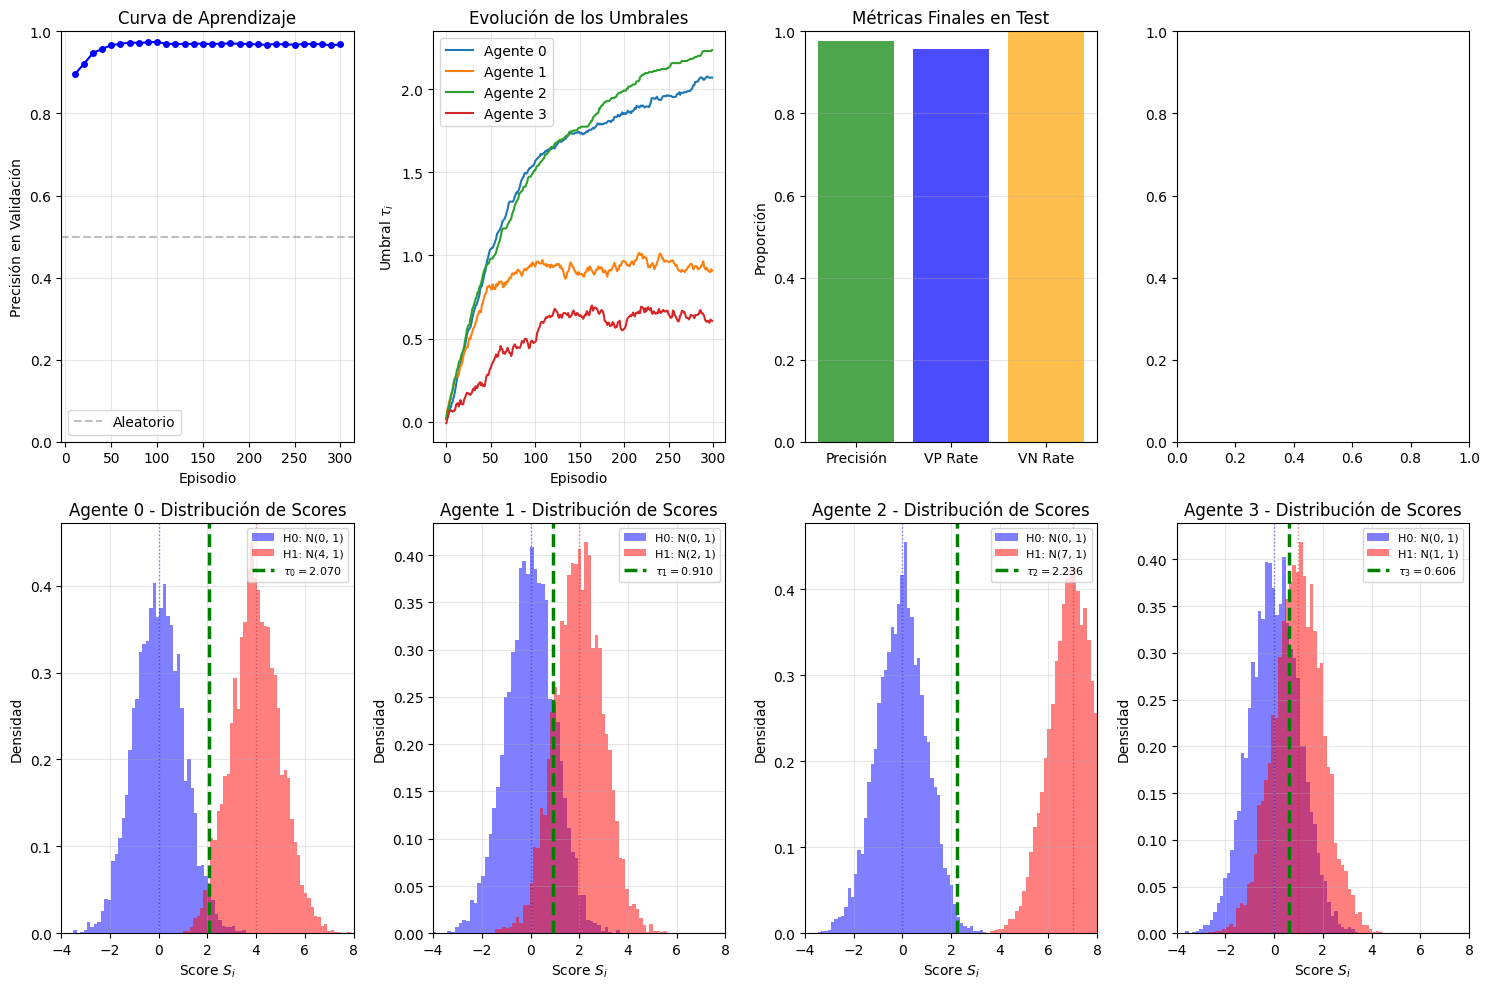

In [65]:
# Crear figura con 2 filas y 3 columnas
fig, axes = plt.subplots(2, 4, figsize=(15, 10))

# ============================================================
# FILA 1: Curva de aprendizaje y evolución de umbrales
# ============================================================

# Gráfica 1: Curva de aprendizaje
ax = axes[0, 0]
if coordinador.historial_episodios:
    ax.plot(coordinador.historial_episodios, coordinador.historial_precision_validacion, 
            'b-o', markersize=4, linewidth=1.5)
ax.set_xlabel('Episodio')
ax.set_ylabel('Precisión en Validación')
ax.set_title('Curva de Aprendizaje')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Aleatorio')
ax.legend()

# Gráfica 2: Evolución de todos los umbrales juntos
ax = axes[0, 1]
for i in range(N_AGENTES):
    ax.plot(coordinador.historial_umbrales[i], label=f'Agente {i}', linewidth=1.5)
ax.set_xlabel('Episodio')
ax.set_ylabel('Umbral $\\tau_i$')
ax.set_title('Evolución de los Umbrales')
ax.legend()
ax.grid(True, alpha=0.3)

# Gráfica 3: Precisión final en test
ax = axes[0, 2]
metricas = ['Precisi\u00f3n', 'VP Rate', 'VN Rate']
valores = [precision_test, vp/(vp+fn) if (vp+fn)>0 else 0, vn/(vn+fp) if (vn+fp)>0 else 0]
colors = ['green', 'blue', 'orange']
ax.bar(metricas, valores, color=colors, alpha=0.7)
ax.set_ylim([0, 1])
ax.set_ylabel('Proporción')
ax.set_title('Métricas Finales en Test')
ax.grid(True, alpha=0.3, axis='y')

# ============================================================
# FILA 2: Distribuciones y umbrales (una por agente)
# ============================================================

for i in range(N_AGENTES):
    ax = axes[1, i]
    
    # Obtener scores de este agente
    scores_h0 = df_train[df_train['theta'] == 0][f'score_{i}'].values
    scores_h1 = df_train[df_train['theta'] == 1][f'score_{i}'].values
    
    # Parámetros teóricos
    params = AGENTES_PARAMS[i]
    
    # Histogramas
    ax.hist(scores_h0, bins=50, alpha=0.5, label=f'H0: N({params["mu0"]}, {params["sigma0"]**2})',
            color='blue', density=True)
    ax.hist(scores_h1, bins=50, alpha=0.5, label=f'H1: N({params["mu1"]}, {params["sigma1"]**2})',
            color='red', density=True)
    
    # Umbral aprendido
    tau_final = umbrales_finales[i]
    ax.axvline(x=tau_final, color='green', linestyle='--', linewidth=2.5,
               label=f'$\\tau_{i} = {tau_final:.3f}$')
    
    # Líneas de medias teóricas
    ax.axvline(x=params['mu0'], color='blue', linestyle=':', alpha=0.5, linewidth=1)
    ax.axvline(x=params['mu1'], color='red', linestyle=':', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('Score $S_i$')
    ax.set_ylabel('Densidad')
    ax.set_title(f'Agente {i} - Distribución de Scores')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(RANGO_SCORES)

plt.tight_layout()
plt.show()

ANÁLISIS DE DESEMPEÑO LOCAL POR AGENTE

Agente 0:
  Umbral final: 2.0700
  Precisión local: 0.9775 (1955/2000)

Agente 1:
  Umbral final: 0.9100
  Precisión local: 0.8395 (1679/2000)

Agente 2:
  Umbral final: 2.2363
  Precisión local: 0.9925 (1985/2000)

Agente 3:
  Umbral final: 0.6062
  Precisión local: 0.6810 (1362/2000)

------------------------------------------------------------
MATRICES DE CONFUSIÓN POR AGENTE
------------------------------------------------------------

Agente 0:
  VP:  981, FP:   18
  FN:   27, VN:  974
  TPR (sensibilidad): 0.9732
  TNR (especificidad): 0.9819

Agente 1:
  VP:  882, FP:  195
  FN:  126, VN:  797
  TPR (sensibilidad): 0.8750
  TNR (especificidad): 0.8034

Agente 2:
  VP: 1008, FP:   15
  FN:    0, VN:  977
  TPR (sensibilidad): 1.0000
  TNR (especificidad): 0.9849

Agente 3:
  VP:  650, FP:  280
  FN:  358, VN:  712
  TPR (sensibilidad): 0.6448
  TNR (especificidad): 0.7177

------------------------------------------------------------
GENERAN

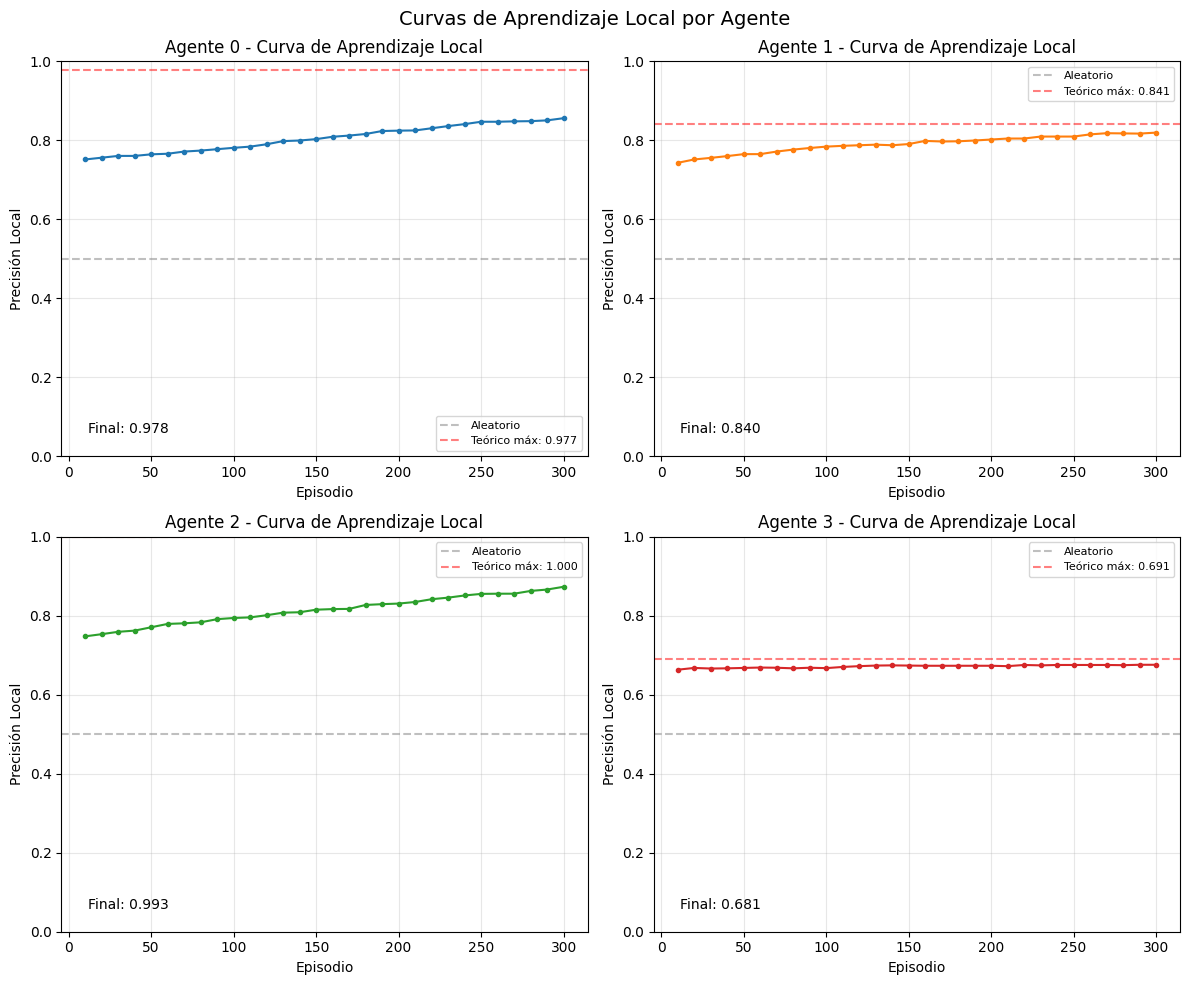

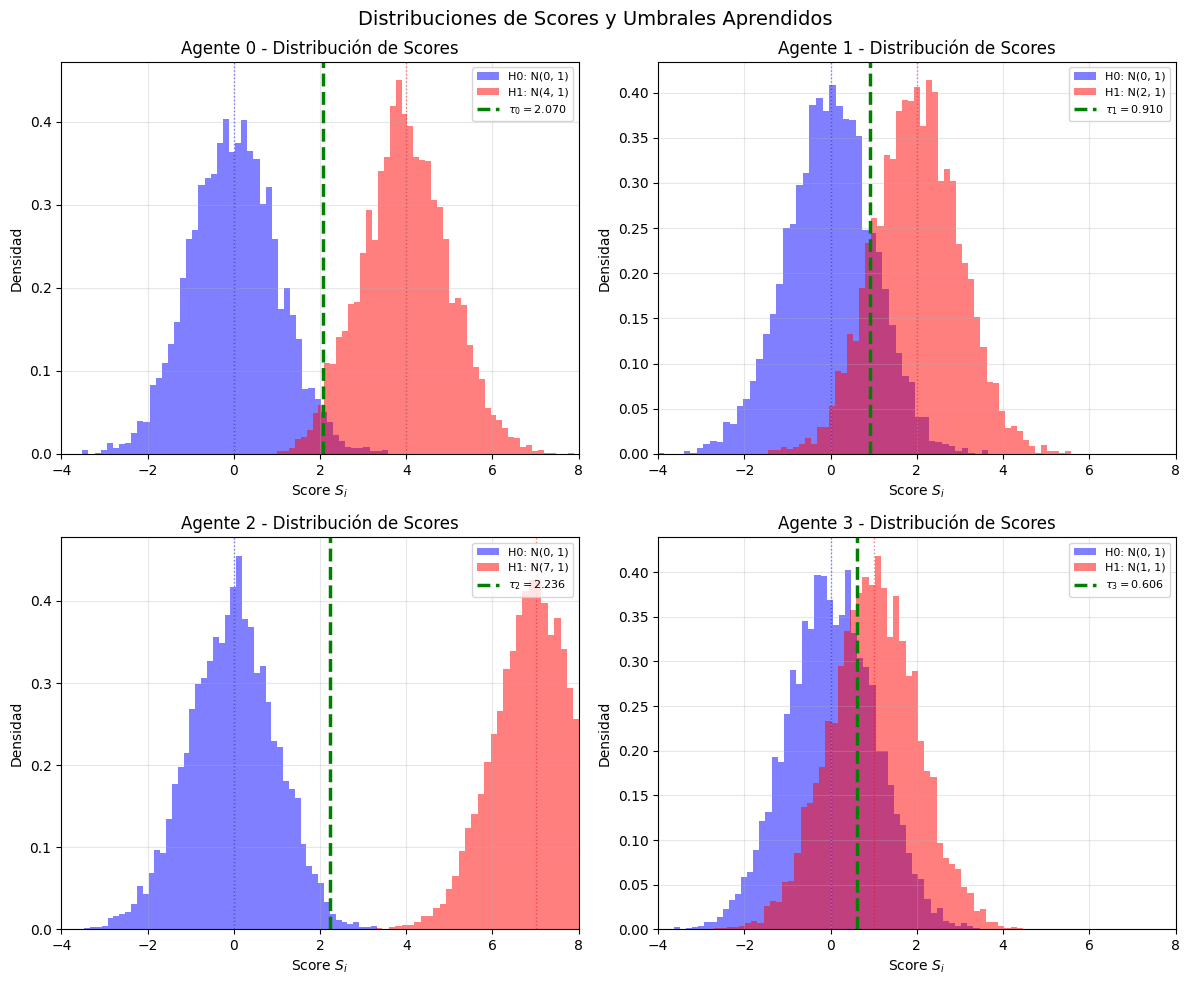


RESUMEN COMPARATIVO: LOCAL vs GLOBAL

| Agente | Umbral | Precisión Local | Precisión Global |
|--------|--------|-----------------|------------------|
|   0    | 2.070 |     0.9775     |       0.9775       |
|   1    | 0.910 |     0.8395     |       0.9775       |
|   2    | 2.236 |     0.9925     |       0.9775       |
|   3    | 0.606 |     0.6810     |       0.9775       |

Precisión del sistema global (votación): 0.9775
Mejor precisión local individual: 0.9925 (Agente 2)

------------------------------------------------------------
ANÁLISIS DE LA VOTACIÓN (Mayoría con 4 agentes)
------------------------------------------------------------

Distribución de votos:
  0 votos a H1: 545 muestras (27.2%)
  1 votos a H1: 390 muestras (19.5%)
  2 votos a H1: 100 muestras (5.0%)
  3 votos a H1: 421 muestras (21.1%)
  4 votos a H1: 544 muestras (27.2%)

Casos donde cada agente fue determinante:
  Agente 0: 421 muestras (21.1%)
  Agente 1: 421 muestras (21.1%)
  Agente 2: 421 muestras (21.1

In [66]:
# ============================================================
# ANÁLISIS DE DESEMPEÑO LOCAL POR AGENTE (4 AGENTES)
# ============================================================

print("=" * 60)
print("ANÁLISIS DE DESEMPEÑO LOCAL POR AGENTE")
print("=" * 60)

# Evaluar precisión local de cada agente en datos de prueba
precisiones_locales = []
for i in range(N_AGENTES):
    aciertos_local = (df_test_pred[f'score_{i}'].apply(
        lambda x: 1 if x >= umbrales_finales[i] else 0
    ) == df_test_pred['theta']).sum()
    precision_local = aciertos_local / len(df_test_pred)
    precisiones_locales.append(precision_local)
    print(f"\nAgente {i}:")
    print(f"  Umbral final: {umbrales_finales[i]:.4f}")
    print(f"  Precisión local: {precision_local:.4f} ({aciertos_local}/{len(df_test_pred)})")

# Matriz de confusión por agente
print("\n" + "-" * 60)
print("MATRICES DE CONFUSIÓN POR AGENTE")
print("-" * 60)

for i in range(N_AGENTES):
    # Decisión local del agente i
    d_i_pred = (df_test_pred[f'score_{i}'] >= umbrales_finales[i]).astype(int)
    theta_true = df_test_pred['theta']
    
    vp = ((d_i_pred == 1) & (theta_true == 1)).sum()
    fp = ((d_i_pred == 1) & (theta_true == 0)).sum()
    vn = ((d_i_pred == 0) & (theta_true == 0)).sum()
    fn = ((d_i_pred == 0) & (theta_true == 1)).sum()
    
    print(f"\nAgente {i}:")
    print(f"  VP: {vp:4d}, FP: {fp:4d}")
    print(f"  FN: {fn:4d}, VN: {vn:4d}")
    tpr = vp/(vp+fn) if (vp+fn)>0 else 0
    tnr = vn/(vn+fp) if (vn+fp)>0 else 0
    print(f"  TPR (sensibilidad): {tpr:.4f}")
    print(f"  TNR (especificidad): {tnr:.4f}")

# ============================================================
# CURVAS DE APRENDIZAJE LOCAL
# ============================================================

print("\n" + "-" * 60)
print("GENERANDO CURVAS DE APRENDIZAJE LOCAL")
print("-" * 60)

# Evaluar precisión local de cada agente en los puntos de validación
precisiones_locales_por_episodio = [[] for _ in range(N_AGENTES)]

for ep_idx, episodio in enumerate(coordinador.historial_episodios):
    # Obtener los umbrales en este episodio
    umbrales_en_episodio = []
    for i in range(N_AGENTES):
        if ep_idx < len(coordinador.historial_umbrales[i]):
            umbrales_en_episodio.append(coordinador.historial_umbrales[i][ep_idx])
        else:
            umbrales_en_episodio.append(umbrales_finales[i])
    
    # Evaluar precisión local de cada agente en validación
    for i in range(N_AGENTES):
        tau_ep = umbrales_en_episodio[i]
        aciertos = 0
        total = len(df_val)
        for idx, fila in df_val.iterrows():
            score = fila[f'score_{i}']
            theta = int(fila['theta'])
            d_i = 1 if score >= tau_ep else 0
            if d_i == theta:
                aciertos += 1
        precision_local = aciertos / total
        precisiones_locales_por_episodio[i].append(precision_local)

# Graficar curvas de aprendizaje local (2x2 para 4 agentes)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(N_AGENTES):
    ax = axes[i]
    ax.plot(coordinador.historial_episodios, precisiones_locales_por_episodio[i], 
            'o-', markersize=3, linewidth=1.5, color=f'C{i}')
    ax.set_xlabel('Episodio')
    ax.set_ylabel('Precisión Local')
    ax.set_title(f'Agente {i} - Curva de Aprendizaje Local')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1])
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Aleatorio')
    
    # Umbral óptimo teórico aproximado (punto medio entre medias)
    params = AGENTES_PARAMS[i]
    umbral_optimo_teorico = (params['mu0'] + params['mu1']) / 2
    
    # Precisión máxima teórica (asumiendo distribuciones normales con igual varianza)
    from scipy.stats import norm
    if params['sigma0'] == params['sigma1']:
        d_prime = (params['mu1'] - params['mu0']) / params['sigma0']
        precision_max_teorica = norm.cdf(d_prime / 2)
        ax.axhline(y=precision_max_teorica, color='red', linestyle='--', alpha=0.5, 
                   label=f'Teórico máx: {precision_max_teorica:.3f}')
    
    ax.legend(fontsize=8)
    ax.text(0.05, 0.05, f'Final: {precisiones_locales[i]:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='bottom')

plt.suptitle('Curvas de Aprendizaje Local por Agente', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZACIÓN DE DISTRIBUCIONES (2x2 para 4 agentes)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(N_AGENTES):
    ax = axes[i]
    
    # Obtener scores de este agente
    scores_h0 = df_train[df_train['theta'] == 0][f'score_{i}'].values
    scores_h1 = df_train[df_train['theta'] == 1][f'score_{i}'].values
    
    # Parámetros teóricos
    params = AGENTES_PARAMS[i]
    
    # Histogramas
    ax.hist(scores_h0, bins=50, alpha=0.5, 
            label=f'H0: N({params["mu0"]}, {params["sigma0"]**2})',
            color='blue', density=True)
    ax.hist(scores_h1, bins=50, alpha=0.5, 
            label=f'H1: N({params["mu1"]}, {params["sigma1"]**2})',
            color='red', density=True)
    
    # Umbral aprendido
    tau_final = umbrales_finales[i]
    ax.axvline(x=tau_final, color='green', linestyle='--', linewidth=2.5,
               label=f'$\\tau_{i} = {tau_final:.3f}$')
    
    # Líneas de medias teóricas
    ax.axvline(x=params['mu0'], color='blue', linestyle=':', alpha=0.5, linewidth=1)
    ax.axvline(x=params['mu1'], color='red', linestyle=':', alpha=0.5, linewidth=1)
    
    ax.set_xlabel('Score $S_i$')
    ax.set_ylabel('Densidad')
    ax.set_title(f'Agente {i} - Distribución de Scores')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(RANGO_SCORES)

plt.suptitle('Distribuciones de Scores y Umbrales Aprendidos', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# RESUMEN COMPARATIVO: LOCAL vs GLOBAL
# ============================================================

print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO: LOCAL vs GLOBAL")
print("=" * 60)

print("\n| Agente | Umbral | Precisión Local | Precisión Global |")
print("|--------|--------|-----------------|------------------|")
for i in range(N_AGENTES):
    print(f"|   {i}    | {umbrales_finales[i]:.3f} |     {precisiones_locales[i]:.4f}     |       {precision_test:.4f}       |")

print(f"\nPrecisión del sistema global (votación): {precision_test:.4f}")
print(f"Mejor precisión local individual: {max(precisiones_locales):.4f} (Agente {np.argmax(precisiones_locales)})")

# ============================================================
# ANÁLISIS DE LA VOTACIÓN (para 4 agentes)
# ============================================================

print("\n" + "-" * 60)
print("ANÁLISIS DE LA VOTACIÓN (Mayoría con 4 agentes)")
print("-" * 60)

# Calcular votación (con 4 agentes, mayoría = al menos 3 votos)
decisiones_globales = df_test_pred['D_g'].values
decisiones_locales = [df_test_pred[f'score_{i}'].apply(
    lambda x: 1 if x >= umbrales_finales[i] else 0
).values for i in range(N_AGENTES)]

# Para mayoría con 4 agentes, se necesita al menos 3 votos
votos_por_muestra = np.column_stack(decisiones_locales).sum(axis=1)
mayoria = (votos_por_muestra >= 3).astype(int)

# Verificar que coincide
if not np.all(mayoria == decisiones_globales):
    print("  Advertencia: Discrepancia en cálculo de mayoría")

print("\nDistribución de votos:")
for v in range(5):
    count = (votos_por_muestra == v).sum()
    print(f"  {v} votos a H1: {count} muestras ({100*count/len(votos_por_muestra):.1f}%)")

print("\nCasos donde cada agente fue determinante:")
for i in range(N_AGENTES):
    # Voto determinante: sin el voto de i, la mayoría cambia
    votos_sin_i = votos_por_muestra - decisiones_locales[i]
    
    # Con 4 agentes, mayoría es 3. Un voto es determinante si:
    # - Sin su voto hay 2 votos (empate) y él vota 1 → da mayoría
    # - Sin su voto hay 3 votos (mayoría) y él vota 0 → quita mayoría
    fue_determinante = (votos_sin_i == 2) & (decisiones_locales[i] == 1)
    fue_determinante_tambien = (votos_sin_i == 3) & (decisiones_locales[i] == 0)
    total_determinante = fue_determinante.sum() + fue_determinante_tambien.sum()
    print(f"  Agente {i}: {total_determinante} muestras ({100*total_determinante/len(df_test_pred):.1f}%)")

# ============================================================
# MATRIZ DE CORRELACIÓN ENTRE AGENTES
# ============================================================

print("\n" + "-" * 60)
print("CORRELACIÓN ENTRE DECISIONES DE AGENTES")
print("-" * 60)

# Matriz de correlación
matriz_corr = np.zeros((N_AGENTES, N_AGENTES))
for i in range(N_AGENTES):
    for j in range(N_AGENTES):
        matriz_corr[i, j] = np.corrcoef(decisiones_locales[i], decisiones_locales[j])[0, 1]

print("\nMatriz de correlación (decisiones):")
print("     " + "".join([f"  Ag{i:2d}" for i in range(N_AGENTES)]))
for i in range(N_AGENTES):
    print(f"Ag{i:2d}: " + "".join([f"{matriz_corr[i,j]:6.3f}" for j in range(N_AGENTES)]))

# Identificar agentes más redundantes
print("\nAgentes más correlacionados (redundantes):")
for i in range(N_AGENTES):
    for j in range(i+1, N_AGENTES):
        if matriz_corr[i, j] > 0.8:
            print(f"  Agente {i} y Agente {j}: {matriz_corr[i, j]:.3f}")

## 8. Predicción en Nuevos Datos

In [67]:
df_nuevos_con_theta = generar_datos_heterogeneos(n_muestras=500, agentes_params=AGENTES_PARAMS)
theta_real = df_nuevos_con_theta['theta'].copy()
df_nuevos = df_nuevos_con_theta.drop('theta', axis=1)

df_predicciones = coordinador.predecir(df_nuevos, [f'score_{i}' for i in range(N_AGENTES)])

print("Predicciones en nuevos datos (primeras 10):")
print(df_predicciones.head(10))

precision_real = (df_predicciones['D_g'] == theta_real).mean()
print(f"\nPrecisión real en nuevos datos: {precision_real:.4f}")

Predicciones en nuevos datos (primeras 10):
    score_0   score_1   score_2   score_3  D_g
0 -1.398389  0.811624  0.575841  1.143675    0
1 -0.595210 -0.832898  1.926451 -0.081892    0
2 -0.399136 -0.223518  1.501295 -0.367627    0
3  3.127733  2.332928  5.426108  0.492277    1
4 -1.166824 -1.649737 -0.531552 -0.315004    0
5  3.755126  2.462074  7.516451  0.985244    1
6 -0.902232 -0.688269 -1.530883 -0.106988    0
7  5.017480  2.090284  7.188649  2.149711    1
8  0.409375  0.155436  1.668548 -0.689595    0
9  2.942174  2.973995  6.270745 -0.919622    1

Precisión real en nuevos datos: 0.9800


## 9. Resumen del Algoritmo

### Distribuciones de los Agentes:

| Agente | Bajo $H_0$ ($\Theta=0$) | Bajo $H_1$ ($\Theta=1$) |
|--------|------------------------|------------------------|
| 0 | $\mathcal{N}(0, 1)$ | $\mathcal{N}(2, 1)$ |
| 1 | $\mathcal{N}(2, 1)$ | $\mathcal{N}(4, 1)$ |
| 2 | $\mathcal{N}(0, 4)$ | $\mathcal{N}(2, 4)$ |

### Entrenamiento:
1. Inicializar $\tau_i$ para cada agente
2. Para cada episodio:
   - Muestrear $(\mathbf{S}, \Theta)$
   - Calcular $d_i = \mathbf{1}_{S_i \geq \tau_i}$
   - Calcular $D_g = \phi(d_1, \dots, d_N)$
   - $r_i = -\beta|d_i-D_g| + \mathbf{1}_{d_i=\Theta} + \alpha\mathbf{1}_{D_g=\Theta}$
   - $\tau_i \leftarrow \tau_i + \eta \nabla_{\tau_i} r_i$

### Predicción:
1. Usar $\tau_i$ aprendidos (fijos)
2. Calcular $d_i = \mathbf{1}_{S_i \geq \tau_i}$
3. Devolver $D_g = \phi(d_1, \dots, d_N)$